# Crowded Orbit: Exploratory Data Analysis

This notebook explores the **UCS Satellite Database** (January 2023 snapshot) containing every known operational satellite orbiting Earth. The goal is to assess data quality, understand the structure of the dataset, and extract early insights that will guide the design of our interactive visualization.

We ground our analysis in the theoretical framework from the COM-480 Data Visualization course, classifying attributes according to **Steven's measurement scales** and identifying the **dataset type** before diving into statistics and plots.

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

os.makedirs("img", exist_ok=True)

# --- Global style ---
sns.set_theme(style="white", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#333333",
    "text.color": "#333333",
    "xtick.color": "#555555",
    "ytick.color": "#555555",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.color": "#cccccc",
    "font.family": "sans-serif",
})

# Color palette
PALETTE = {
    "main": "#1a73e8",
    "accent": "#e8710a",
    "LEO": "#1a73e8",
    "MEO": "#e8710a",
    "GEO": "#34a853",
    "Elliptical": "#9334e6",
}

# Load the dataset (latin-1 encoding due to non-breaking spaces in some fields)
df = pd.read_csv("../../data/UCS-Satellite-Database-Officialname-1-1-2023.csv", encoding="latin-1")

# Drop the many empty trailing columns and the source columns
# Keep only the 27 meaningful fields (columns 0-26)
df = df.iloc[:, :27]

# Clean column names: strip whitespace
df.columns = df.columns.str.strip()

print(f"Dataset shape: {df.shape[0]} satellites x {df.shape[1]} attributes")
df.head(3)

Dataset shape: 6718 satellites x 27 attributes


,Current Official Name of Satellite,Country/Org of UN Registry,Country of Operator/Owner,Operator/Owner,Users,Purpose,Detailed Purpose,Class of Orbit,Type of Orbit,Longitude of GEO (degrees),...,Power (watts),Date of Launch,Expected Lifetime (yrs.),Contractor,Country of Contractor,Launch Site,Launch Vehicle,COSPAR Number,NORAD Number,Comments
0,1HOPSAT-TD,NR,USA,Hera Systems,Commercial,Earth Observation,Infrared Imaging,LEO,Non-Polar Inclined,0.0,...,NaN,11-12-2019,0.5,Hera Systems,USA,Satish Dhawan Space Centre,PSLV,2019-089H,44859,Pathfinder for planned earth observation const...
1,Aalto-1,Finland,Finland,Aalto University,Civil,Technology Development,NaN,LEO,Sun-Synchronous,0.0,...,4.50,23-06-2017,2.0,Aalto University,Finland,Satish Dhawan Space Centre,PSLV,2017-036L,42775,Technology development and education.
2,AAt-4,Denmark,Denmark,University of Aalborg,Civil,Earth Observation,Automatic Identification System (AIS),LEO,Sun-Synchronous,0.0,...,NaN,25-04-2016,NaN,University of Aalborg,Denmark,Guiana Space Center,Soyuz-2.1a,2016-025E,41460,Carries AIS system.


## 2. Data Abstraction and Attribute Classification

Before any analysis, we classify the dataset and its attributes following the course framework.

### Dataset Type

According to the course taxonomy, this is a **flat table** (also called an item-attribute table). Each row is an **item** (one satellite) and each column is an **attribute** describing that item. There are no explicit links between items, so this is not a network or tree. However, we can *derive* networks later (e.g., shared operators, shared launch vehicles) and spatial structures (orbital positions).

### Attribute Classification (Stevens' Scales)

We classify each attribute by its measurement scale to guide our choice of visual encodings:

| Attribute | Scale | Reasoning |
|---|---|---|
| Satellite Name | **Nominal** | Unique label, no ordering |
| Country of Operator/Owner | **Nominal** | Categorical, no natural order |
| Operator/Owner | **Nominal** | Categorical label |
| Users (Commercial, Military, ...) | **Nominal** | Categories without inherent ranking |
| Purpose (Communications, Earth Observation, ...) | **Nominal** | Functional category |
| Class of Orbit (LEO, MEO, GEO, Elliptical) | **Ordinal** | Ordered by altitude: LEO < MEO < GEO |
| Type of Orbit | **Nominal** | Categorical (Sun-Synchronous, Polar, ...) |
| Perigee / Apogee (km) | **Ratio** | True zero (Earth's surface), supports all arithmetic |
| Eccentricity | **Ratio** | True zero (circular orbit = 0) |
| Inclination (degrees) | **Ratio** | True zero (equatorial orbit = 0) |
| Period (minutes) | **Ratio** | True zero, meaningful ratios |
| Launch Mass (kg) | **Ratio** | True zero, meaningful ratios |
| Power (watts) | **Ratio** | True zero |
| Date of Launch | **Interval** | Ordered with measurable differences, but no true zero |
| Expected Lifetime (years) | **Ratio** | True zero, meaningful ratios |
| Launch Site | **Nominal** | Categorical location label |
| Launch Vehicle | **Nominal** | Categorical label |

This classification will directly inform our visual encoding choices later: **nominal** attributes map well to color hue and spatial grouping, **ordinal** to ordered color palettes and position, **ratio** to length, area, and position on a continuous axis.

## 3. Data Quality Assessment

In [2]:
# Missing values overview
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
quality = pd.DataFrame({"Missing": missing, "% Missing": missing_pct, "Unique": df.nunique()})
quality = quality[quality["Missing"] > 0].sort_values("% Missing", ascending=False)
print("Columns with missing values:\n")
quality

Columns with missing values:



,Missing,% Missing,Unique
Dry Mass (kg.),6274,93.4,171
Power (watts),6137,91.4,152
Detailed Purpose,5551,82.6,52
Comments,4882,72.7,1287
Expected Lifetime (yrs.),1914,28.5,28
Type of Orbit,641,9.5,8
Launch Mass (kg.),243,3.6,566
Period (minutes),44,0.7,579
Longitude of GEO (degrees),2,0.0,445


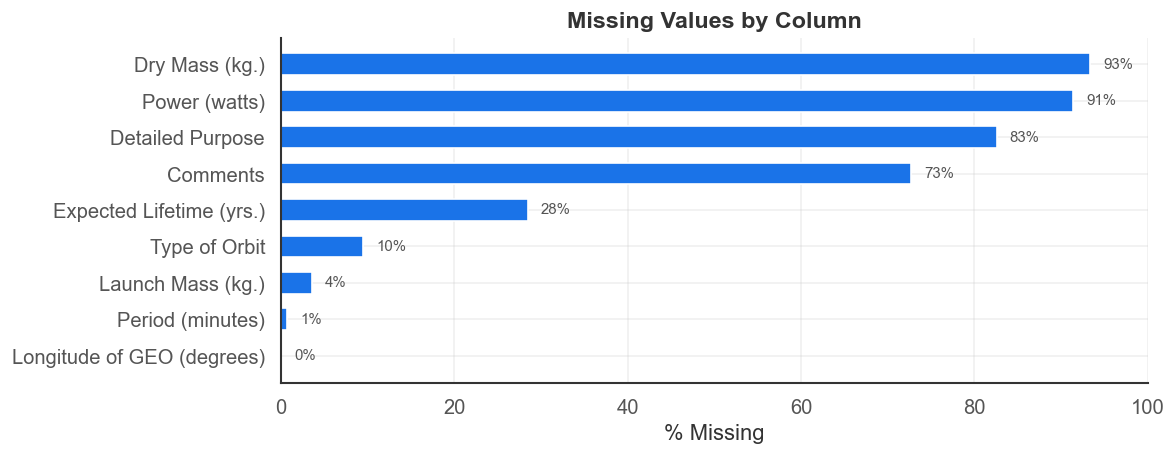


Dry Mass is missing for 93% of satellites.
Power is missing for 91% of satellites.
These two columns are too sparse to use reliably. We will drop them.

Detailed Purpose is missing for 83% but the broader 'Purpose' column is complete.


In [3]:
# Visualize missingness as a clean horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 4))
cols_ordered = quality.sort_values("% Missing", ascending=True).index
vals = quality.loc[cols_ordered, "% Missing"]
bars = ax.barh(cols_ordered, vals, color=PALETTE["main"], height=0.6)
ax.set_xlabel("% Missing")
ax.set_title("Missing Values by Column", fontweight="bold", fontsize=14)
ax.set_xlim(0, 100)
for bar, v in zip(bars, vals):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            f"{v:.0f}%", va="center", fontsize=9, color="#555555")
plt.tight_layout()
plt.show()

print(f"\nDry Mass is missing for {missing_pct['Dry Mass (kg.)']:.0f}% of satellites.")
print(f"Power is missing for {missing_pct['Power (watts)']:.0f}% of satellites.")
print("These two columns are too sparse to use reliably. We will drop them.")
print(f"\nDetailed Purpose is missing for {missing_pct['Detailed Purpose']:.0f}% but the broader 'Purpose' column is complete.")

## 4. Preprocessing

We now clean and enrich the dataset with derived features that will support our visualizations.

In [4]:

df["Class of Orbit"] = df["Class of Orbit"].str.strip().replace("LEo", "LEO")
print("Orbit classes after cleaning:", df["Class of Orbit"].unique())

# --- Parse numeric columns stored as strings ---
numeric_cols = ["Perigee (km)", "Apogee (km)", "Inclination (degrees)", 
                "Period (minutes)", "Launch Mass (kg.)"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(",", "").str.strip(), errors="coerce")

# --- Parse launch date ---
df["Launch Date"] = pd.to_datetime(df["Date of Launch"], format="mixed", dayfirst=True, errors="coerce")
df["Launch Year"] = df["Launch Date"].dt.year.astype("Int64")
df["Launch Decade"] = (df["Launch Year"] // 10 * 10).astype("Int64")

# --- Compute altitude (average of perigee and apogee) ---
df["Altitude (km)"] = (df["Perigee (km)"] + df["Apogee (km)"]) / 2

# --- Simplify multi-purpose to primary purpose ---
df["Primary Purpose"] = df["Purpose"].str.split("/").str[0].str.strip()

# --- Simplify multi-user to primary user ---
df["Primary User"] = df["Users"].str.split("/").str[0].str.strip()

# --- Drop overly sparse columns ---
df = df.drop(columns=["Dry Mass (kg.)", "Power (watts)", "Detailed Purpose"])

print(f"\nCleaned dataset: {df.shape[0]} satellites x {df.shape[1]} attributes")
print(f"Launch years range: {df['Launch Year'].min()} to {df['Launch Year'].max()}")
print(f"Altitude range: {df['Altitude (km)'].min():.0f} km to {df['Altitude (km)'].max():.0f} km")

Orbit classes after cleaning: <StringArray>
['LEO', 'GEO', 'Elliptical', 'MEO']
Length: 4, dtype: str

Cleaned dataset: 6718 satellites x 30 attributes
Launch years range: 18 to 2022
Altitude range: 150 km to 194794 km


## 5. Overview Statistics

We start with broad descriptive statistics to understand the scale and distribution of the data.

In [5]:
print("=== Key Figures ===")
print(f"Total operational satellites:  {len(df):,}")
print(f"Unique countries (operator):  {df['Country of Operator/Owner'].nunique()}")
print(f"Unique operators:             {df['Operator/Owner'].nunique()}")
print(f"Unique launch vehicles:       {df['Launch Vehicle'].nunique()}")
print(f"Unique launch sites:          {df['Launch Site'].nunique()}")
print()

print("=== Orbit Class Distribution ===")
orbit_counts = df["Class of Orbit"].value_counts()
for orbit, count in orbit_counts.items():
    print(f"  {orbit:12s} {count:5d}  ({count/len(df)*100:.1f}%)")
print()

print("=== Primary User Distribution ===")
user_counts = df["Primary User"].value_counts()
for user, count in user_counts.items():
    print(f"  {user:14s} {count:5d}  ({count/len(df)*100:.1f}%)")
print()

print("=== Top 10 Primary Purposes ===")
purpose_counts = df["Primary Purpose"].value_counts().head(10)
for purpose, count in purpose_counts.items():
    print(f"  {purpose:35s} {count:5d}  ({count/len(df)*100:.1f}%)")

=== Key Figures ===
Total operational satellites:  6,718
Unique countries (operator):  104
Unique operators:             639
Unique launch vehicles:       164
Unique launch sites:          39

=== Orbit Class Distribution ===
  LEO           5937  (88.4%)
  GEO            580  (8.6%)
  MEO            142  (2.1%)
  Elliptical      59  (0.9%)

=== Primary User Distribution ===
  Commercial      5280  (78.6%)
  Government       688  (10.2%)
  Military         588  (8.8%)
  Civil            162  (2.4%)

=== Top 10 Primary Purposes ===
  Communications                       4823  (71.8%)
  Earth Observation                    1167  (17.4%)
  Technology Development                368  (5.5%)
  Navigation                            154  (2.3%)
  Space Science                         100  (1.5%)
  Technology Demonstration               42  (0.6%)
  Earth Science                          23  (0.3%)
  Surveillance                           14  (0.2%)
  Unknown                                10  

## 6. Temporal Analysis: The Growth of Orbital Space

One of our core narrative axes is how orbital space went from nearly empty to crowded. We look at launch frequency over time and compute a cumulative curve to show the acceleration.

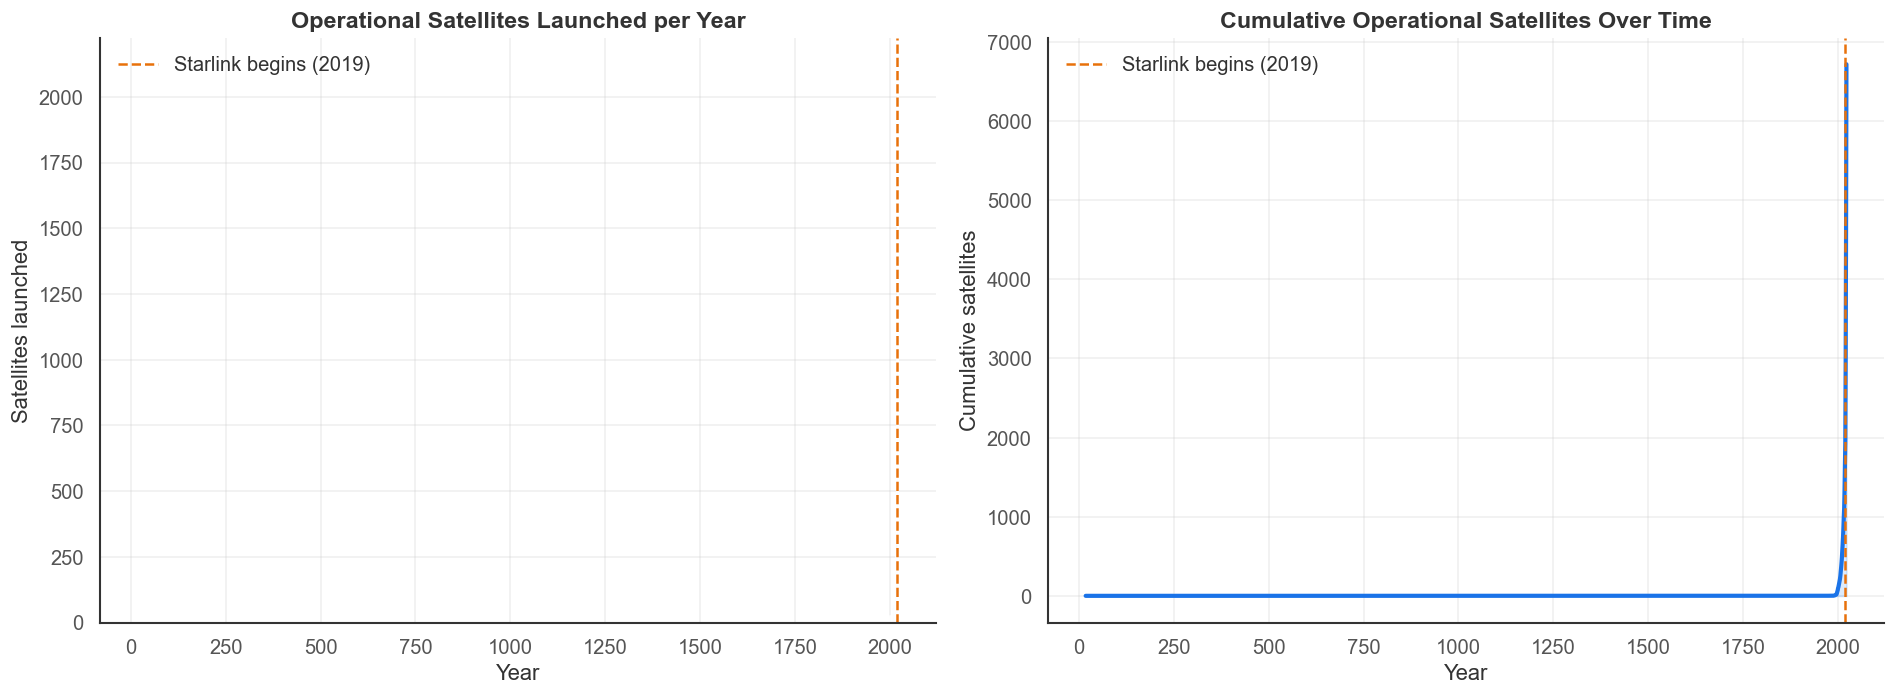


Satellites launched from 2019 onward: 5,071 (75.5% of all operational satellites)
The acceleration is dramatic: the majority of satellites currently in orbit were launched in the last few years.


In [6]:
launches_by_year = df.groupby("Launch Year").size().reset_index(name="Count")
launches_by_year["Cumulative"] = launches_by_year["Count"].cumsum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart: launches per year
ax1.bar(launches_by_year["Launch Year"], launches_by_year["Count"],
        color=PALETTE["main"], width=0.8, alpha=0.85)
ax1.axvline(x=2019, color=PALETTE["accent"], linestyle="--", linewidth=1.5,
            label="Starlink begins (2019)")
ax1.set_xlabel("Year")
ax1.set_ylabel("Satellites launched")
ax1.set_title("Operational Satellites Launched per Year", fontweight="bold", fontsize=14)
ax1.legend(frameon=False)

# Cumulative area
ax2.fill_between(launches_by_year["Launch Year"], launches_by_year["Cumulative"],
                 color=PALETTE["main"], alpha=0.15)
ax2.plot(launches_by_year["Launch Year"], launches_by_year["Cumulative"],
         color=PALETTE["main"], linewidth=2.5)
ax2.axvline(x=2019, color=PALETTE["accent"], linestyle="--", linewidth=1.5,
            label="Starlink begins (2019)")
ax2.set_xlabel("Year")
ax2.set_ylabel("Cumulative satellites")
ax2.set_title("Cumulative Operational Satellites Over Time", fontweight="bold", fontsize=14)
ax2.legend(frameon=False)

plt.tight_layout()
plt.savefig("img/cumulative_launches.png", bbox_inches="tight", facecolor="white", dpi=150)
plt.show()

post_2019 = df[df["Launch Year"] >= 2019].shape[0]
print(f"\nSatellites launched from 2019 onward: {post_2019:,} ({post_2019/len(df)*100:.1f}% of all operational satellites)")
print("The acceleration is dramatic: the majority of satellites currently in orbit were launched in the last few years.")

## 7. Geopolitical Landscape: Who Owns Orbital Space?

Following the course principle that **nominal attributes are best encoded with spatial grouping and color hue**, we use bar charts and a proportional breakdown to show country-level dominance.

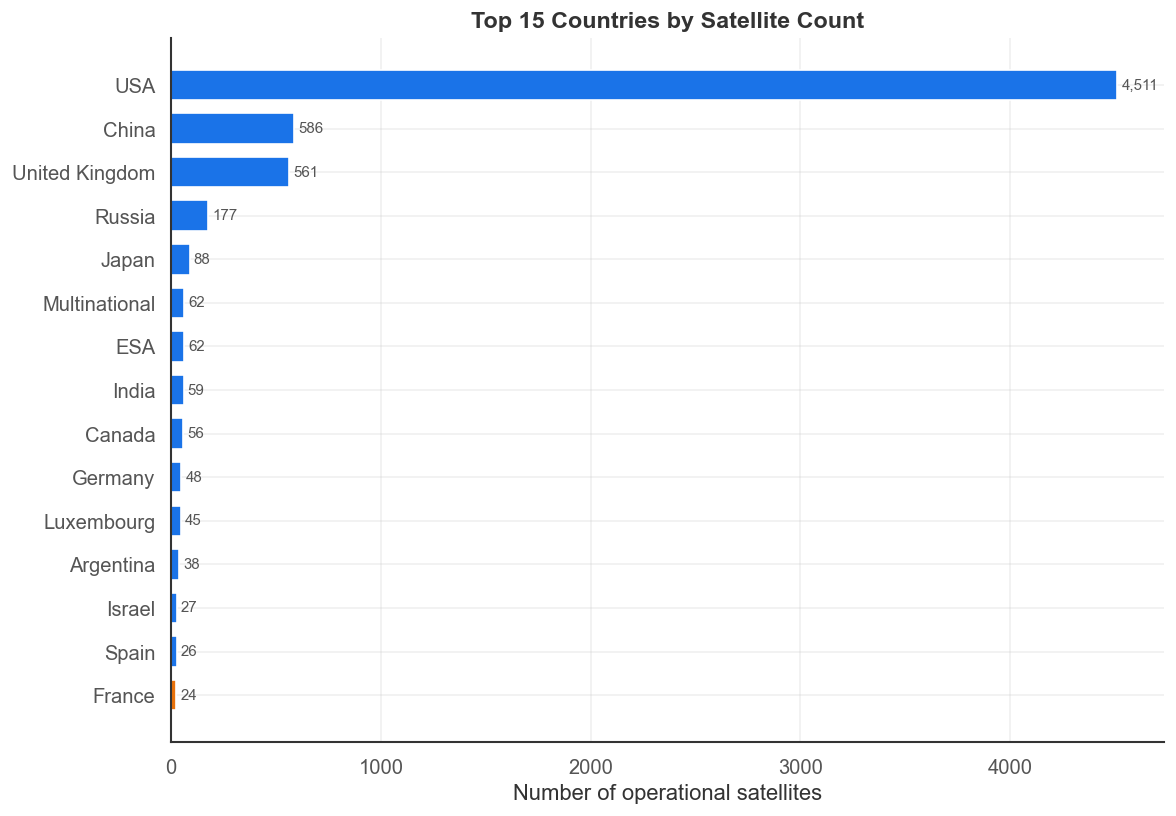


USA alone operates 4,511 satellites (67.1% of global total).
The top 3 countries account for the vast majority of orbital presence.


In [7]:
# Top 15 countries by number of operational satellites
top_countries = df["Country of Operator/Owner"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [PALETTE["accent"] if i == len(top_countries) - 1 else PALETTE["main"]
          for i in range(len(top_countries))]
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1],
               color=colors[::-1], height=0.7)
ax.set_xlabel("Number of operational satellites")
ax.set_title("Top 15 Countries by Satellite Count", fontweight="bold", fontsize=14)

for bar, val in zip(bars, top_countries.values[::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=9, color="#555555")

plt.tight_layout()
plt.savefig("img/top_countries.png", bbox_inches="tight", facecolor="white", dpi=150)
plt.show()

usa_count = top_countries.get("USA", 0)
print(f"\nUSA alone operates {usa_count:,} satellites ({usa_count/len(df)*100:.1f}% of global total).")
print(f"The top 3 countries account for the vast majority of orbital presence.")

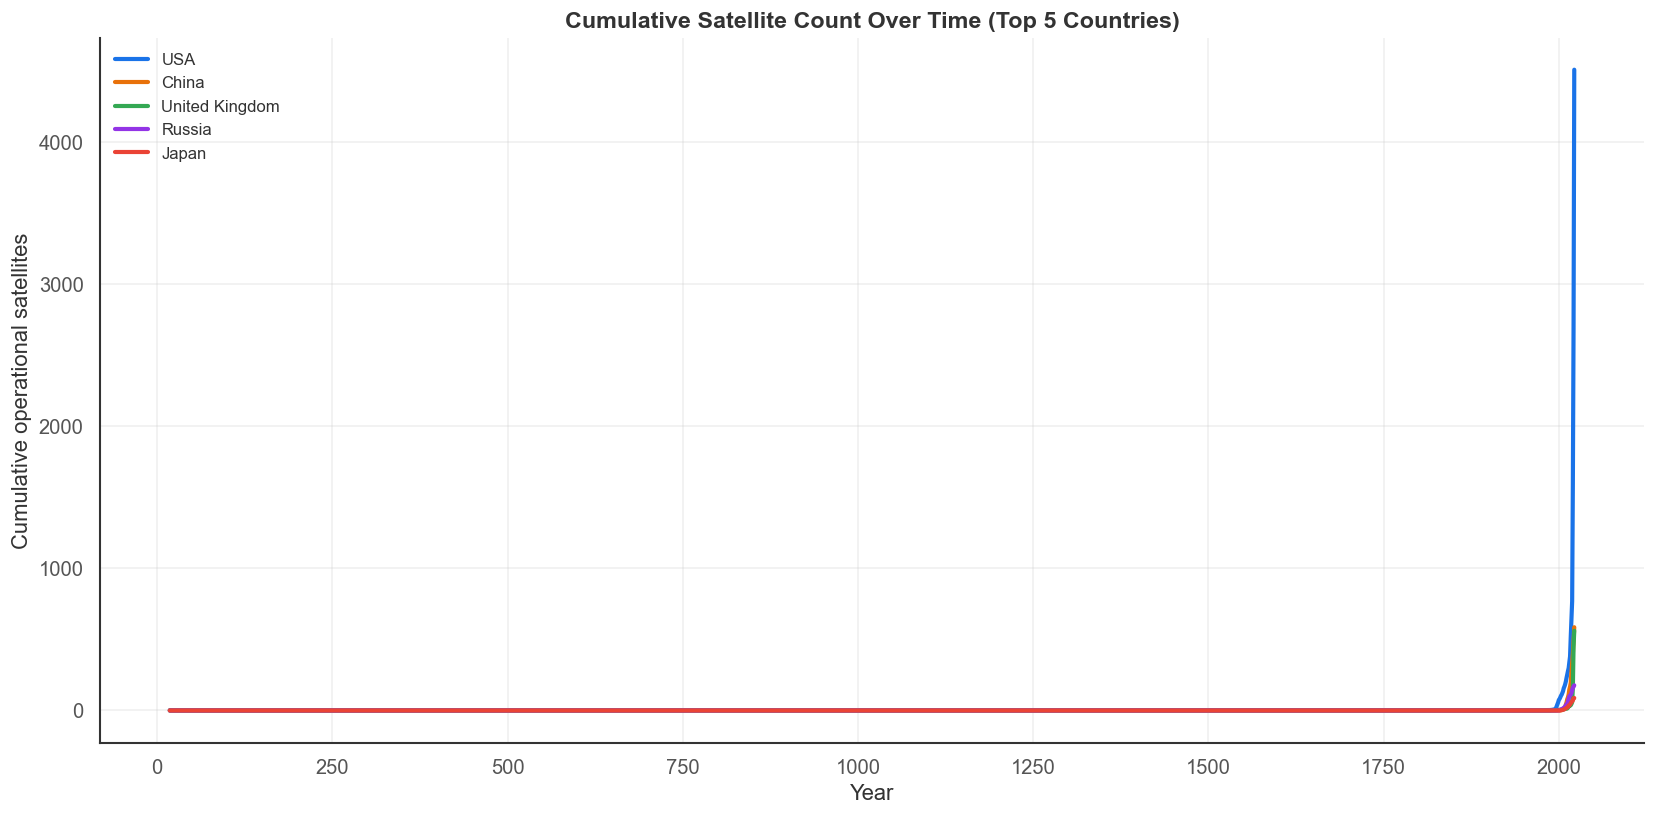

In [8]:
# Evolution of top 5 countries over time
top5 = df["Country of Operator/Owner"].value_counts().head(5).index.tolist()
yearly_country = (df[df["Country of Operator/Owner"].isin(top5)]
                  .groupby(["Launch Year", "Country of Operator/Owner"])
                  .size()
                  .unstack(fill_value=0))
yearly_country_cum = yearly_country.cumsum()

country_colors = ["#1a73e8", "#e8710a", "#34a853", "#9334e6", "#ea4335"]
fig, ax = plt.subplots(figsize=(14, 7))
for i, country in enumerate(top5):
    if country in yearly_country_cum.columns:
        ax.plot(yearly_country_cum.index, yearly_country_cum[country],
                linewidth=2.5, label=country, color=country_colors[i])
ax.set_xlabel("Year")
ax.set_ylabel("Cumulative operational satellites")
ax.set_title("Cumulative Satellite Count Over Time (Top 5 Countries)", fontweight="bold", fontsize=14)
ax.legend(fontsize=10, frameon=False)
plt.tight_layout()
plt.show()

## 8. Orbital Structure: Where Are Satellites?

The orbital distribution is central to our "crowded orbit" narrative. We examine how satellites distribute across orbital classes and altitudes.

From a visualization theory perspective, altitude is a **ratio** attribute (true zero at Earth's surface), so we can use **position on a continuous axis** and **length** as channels. Orbit class is **ordinal** (LEO < MEO < GEO), so we use an **ordered spatial layout**.

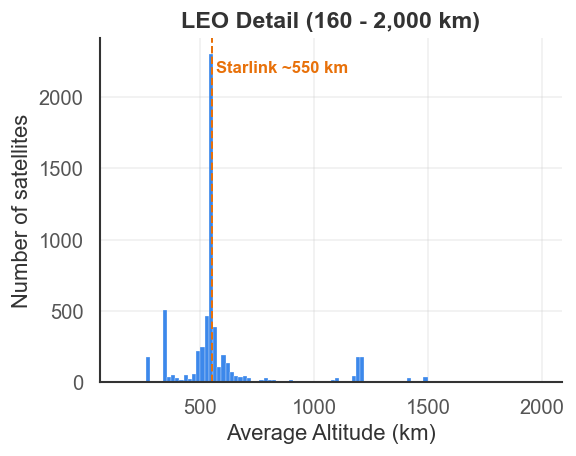

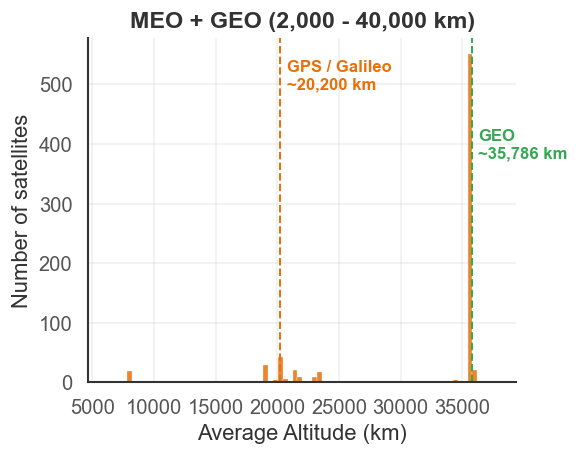

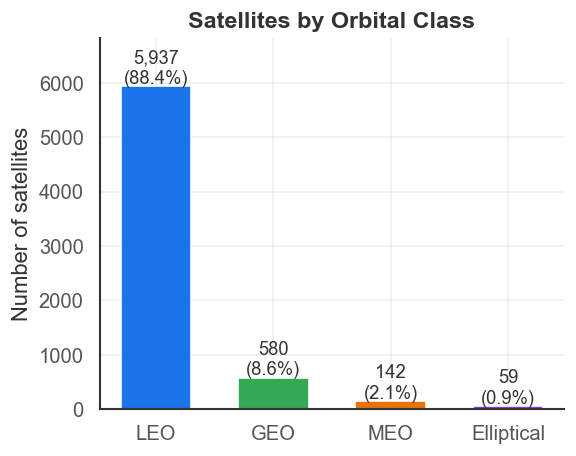


LEO dominates with 88.4% of all operational satellites.
Splitting the altitude view reveals structure invisible in a single histogram:
  - LEO has a sharp spike at ~550 km (Starlink) and secondary peaks for other constellations
  - MEO shows distinct navigation constellation bands around 20,200 km
  - GEO forms a tight spike at 35,786 km


In [9]:
# --- Plot 1: LEO zoom  ---
fig, ax = plt.subplots(figsize=(5, 4))
leo_alt = df["Altitude (km)"].dropna()
leo_alt = leo_alt[leo_alt <= 2000]
ax.hist(leo_alt, bins=100, color=PALETTE["LEO"], edgecolor="white", linewidth=0.2, alpha=0.85)
ax.set_xlabel("Average Altitude (km)")
ax.set_ylabel("Number of satellites")
ax.set_title("LEO Detail (160 - 2,000 km)", fontweight="bold", fontsize=14)
ax.axvline(x=550, color=PALETTE["accent"], linestyle="--", linewidth=1.2)
ax.text(570, ax.get_ylim()[1]*0.9, "Starlink ~550 km", fontsize=10,
        color=PALETTE["accent"], fontweight="bold")
plt.tight_layout()
plt.show()

# --- Plot 2: MEO + GEO range ---
fig, ax = plt.subplots(figsize=(5, 4))
meo_geo = df["Altitude (km)"].dropna()
meo_geo = meo_geo[(meo_geo > 2000) & (meo_geo <= 40000)]
ax.hist(meo_geo, bins=80, color=PALETTE["MEO"], edgecolor="white", linewidth=0.2, alpha=0.85)
ax.set_xlabel("Average Altitude (km)")
ax.set_ylabel("Number of satellites")
ax.set_title("MEO + GEO (2,000 - 40,000 km)", fontweight="bold", fontsize=14)
ax.axvline(x=20200, color=PALETTE["MEO"], linestyle="--", linewidth=1.2)
ax.text(20800, ax.get_ylim()[1]*0.85, "GPS / Galileo\n~20,200 km", fontsize=10,
        color=PALETTE["MEO"], fontweight="bold")
ax.axvline(x=35786, color=PALETTE["GEO"], linestyle="--", linewidth=1.2)
ax.text(36300, ax.get_ylim()[1]*0.65, "GEO\n~35,786 km", fontsize=10,
        color=PALETTE["GEO"], fontweight="bold")
plt.tight_layout()
plt.show()

# --- Plot 3: Orbit class bar chart (replaces donut) ---
fig, ax = plt.subplots(figsize=(5, 4))
orbit_dist = df["Class of Orbit"].value_counts()
orbit_cols = [PALETTE.get(o, "#999999") for o in orbit_dist.index]
bars = ax.bar(orbit_dist.index, orbit_dist.values, color=orbit_cols, width=0.6,
              edgecolor="white", linewidth=1)
ax.set_ylabel("Number of satellites")
ax.set_title("Satellites by Orbital Class", fontweight="bold", fontsize=14)
for bar, val in zip(bars, orbit_dist.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{val:,}\n({pct:.1f}%)", ha="center", fontsize=11, color="#333333")
ax.set_ylim(0, orbit_dist.max() * 1.15)
plt.tight_layout()
plt.show()

leo_pct = orbit_dist.get("LEO", 0) / len(df) * 100
print(f"\nLEO dominates with {leo_pct:.1f}% of all operational satellites.")
print("Splitting the altitude view reveals structure invisible in a single histogram:")
print("  - LEO has a sharp spike at ~550 km (Starlink) and secondary peaks for other constellations")
print("  - MEO shows distinct navigation constellation bands around 20,200 km")
print("  - GEO forms a tight spike at 35,786 km")


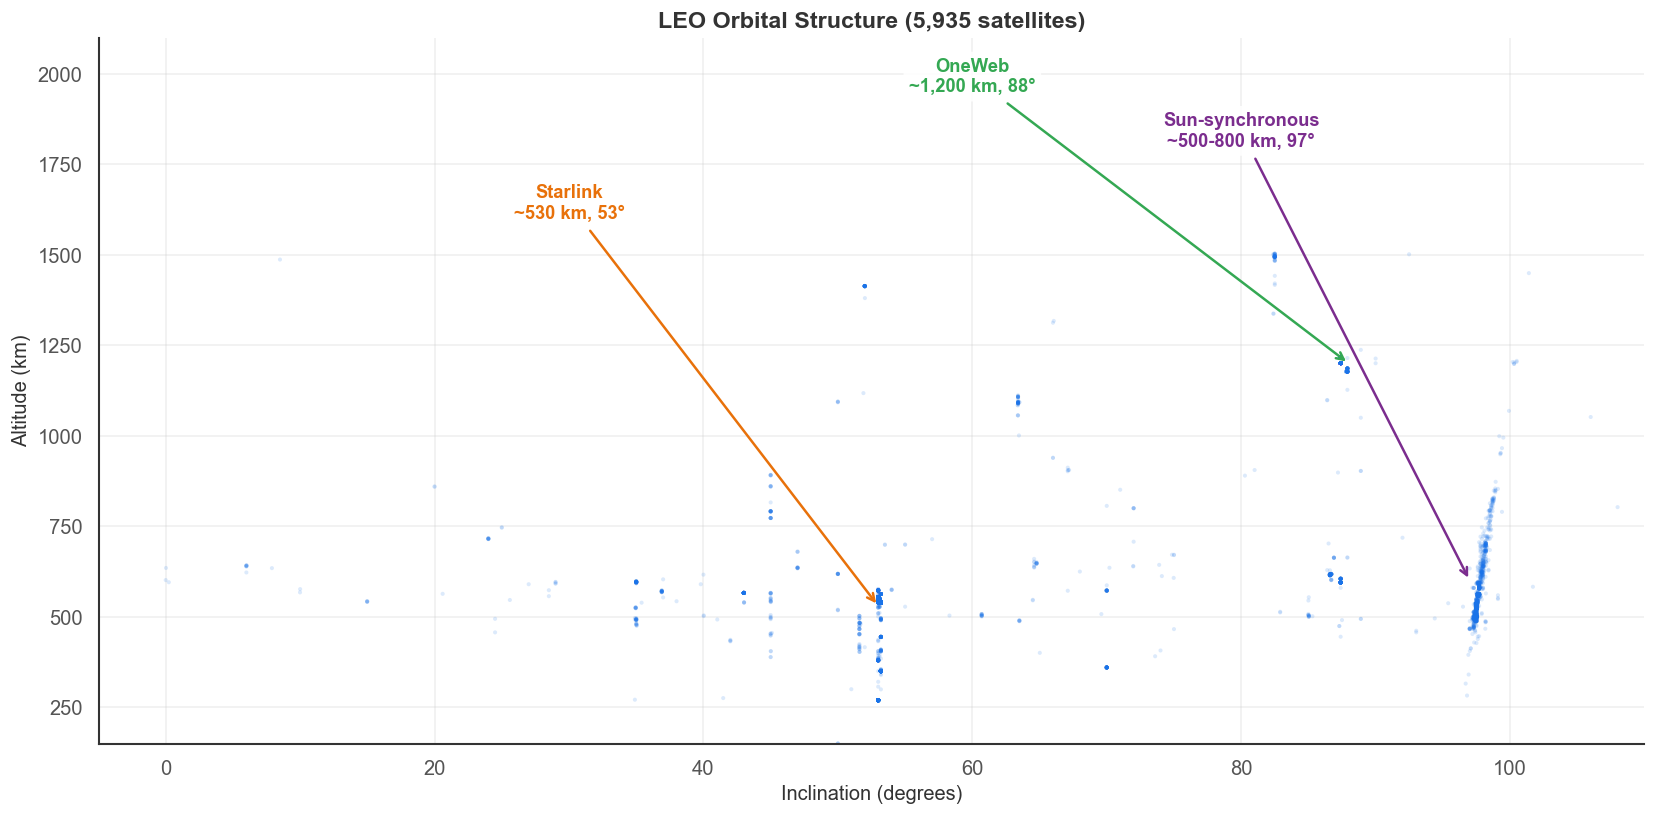

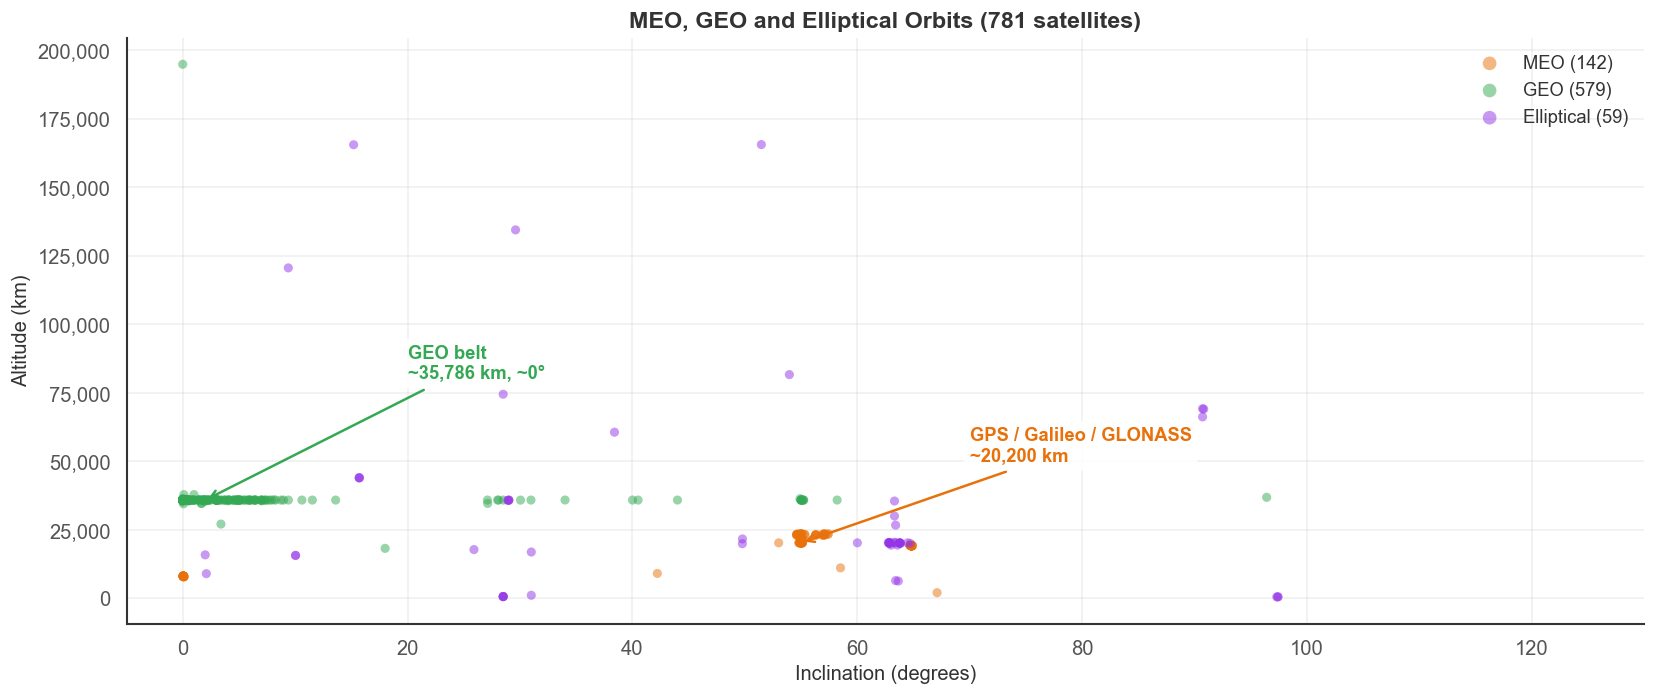

Splitting LEO from the rest reveals two very different stories:
  - LEO is dominated by mega-constellations with tight altitude/inclination clusters
  - MEO/GEO is sparser but strategically critical (navigation, comms)


In [10]:
# Orbital structure
scatter_df = df[(df["Inclination (degrees)"] >= 0) & (df["Inclination (degrees)"] <= 180)
                & (df["Altitude (km)"] > 0)].copy()

# --- Panel 1: LEO only (linear scale, where the density actually matters) ---
fig, ax = plt.subplots(figsize=(14, 7))
leo = scatter_df[scatter_df["Class of Orbit"] == "LEO"]
ax.scatter(leo["Inclination (degrees)"], leo["Altitude (km)"],
           alpha=0.15, s=6, c=PALETTE["LEO"], edgecolors="none")
ax.set_xlabel("Inclination (degrees)", fontsize=12)
ax.set_ylabel("Altitude (km)", fontsize=12)
ax.set_title("LEO Orbital Structure (5,935 satellites)", fontweight="bold", fontsize=14)
ax.set_xlim(-5, 110)
ax.set_ylim(150, 2100)

# Clean annotations with bbox background so text is always readable
bbox = dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="none", alpha=0.85)
ax.annotate("Starlink\n~530 km, 53\u00b0", xy=(53, 530), fontsize=11, fontweight="bold",
            color=PALETTE["accent"], ha="center", xytext=(30, 1600),
            arrowprops=dict(arrowstyle="->", color=PALETTE["accent"], lw=1.5),
            bbox=bbox)
ax.annotate("Sun-synchronous\n~500-800 km, 97\u00b0", xy=(97, 600), fontsize=11, fontweight="bold",
            color="#7b2d8e", ha="center", xytext=(80, 1800),
            arrowprops=dict(arrowstyle="->", color="#7b2d8e", lw=1.5),
            bbox=bbox)
ax.annotate("OneWeb\n~1,200 km, 88\u00b0", xy=(88, 1200), fontsize=11, fontweight="bold",
            color=PALETTE["GEO"], ha="center", xytext=(60, 1950),
            arrowprops=dict(arrowstyle="->", color=PALETTE["GEO"], lw=1.5),
            bbox=bbox)
plt.tight_layout()
plt.savefig("img/leo_scatter.png", bbox_inches="tight", facecolor="white", dpi=150)
plt.show()

# --- Panel 2: MEO + GEO + Elliptical (the non-LEO satellites) ---
fig, ax = plt.subplots(figsize=(14, 6))
for orbit_class in ["MEO", "GEO", "Elliptical"]:
    sub = scatter_df[scatter_df["Class of Orbit"] == orbit_class]
    ax.scatter(sub["Inclination (degrees)"], sub["Altitude (km)"],
               alpha=0.5, s=30, c=PALETTE[orbit_class], edgecolors="none",
               label=f"{orbit_class} ({len(sub):,})")

ax.set_xlabel("Inclination (degrees)", fontsize=12)
ax.set_ylabel("Altitude (km)", fontsize=12)
ax.set_title("MEO, GEO and Elliptical Orbits (781 satellites)", fontweight="bold", fontsize=14)
ax.set_xlim(-5, 130)
ax.legend(fontsize=11, frameon=False, markerscale=1.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

ax.annotate("GEO belt\n~35,786 km, ~0\u00b0", xy=(2, 35786), fontsize=11, fontweight="bold",
            color=PALETTE["GEO"], ha="left", xytext=(20, 80000),
            arrowprops=dict(arrowstyle="->", color=PALETTE["GEO"], lw=1.5),
            bbox=bbox)
ax.annotate("GPS / Galileo / GLONASS\n~20,200 km", xy=(55, 20200), fontsize=11, fontweight="bold",
            color=PALETTE["MEO"], ha="left", xytext=(70, 50000),
            arrowprops=dict(arrowstyle="->", color=PALETTE["MEO"], lw=1.5),
            bbox=bbox)
plt.tight_layout()
plt.show()

print("Splitting LEO from the rest reveals two very different stories:")
print("  - LEO is dominated by mega-constellations with tight altitude/inclination clusters")
print("  - MEO/GEO is sparser but strategically critical (navigation, comms)")

## 9. Purpose Analysis: What Is Orbit Used For?

Purpose is a **nominal** attribute. Following the course guidelines on visual channels, we encode it with **color hue** (good for nominal data) and use **length/position** to show quantities.

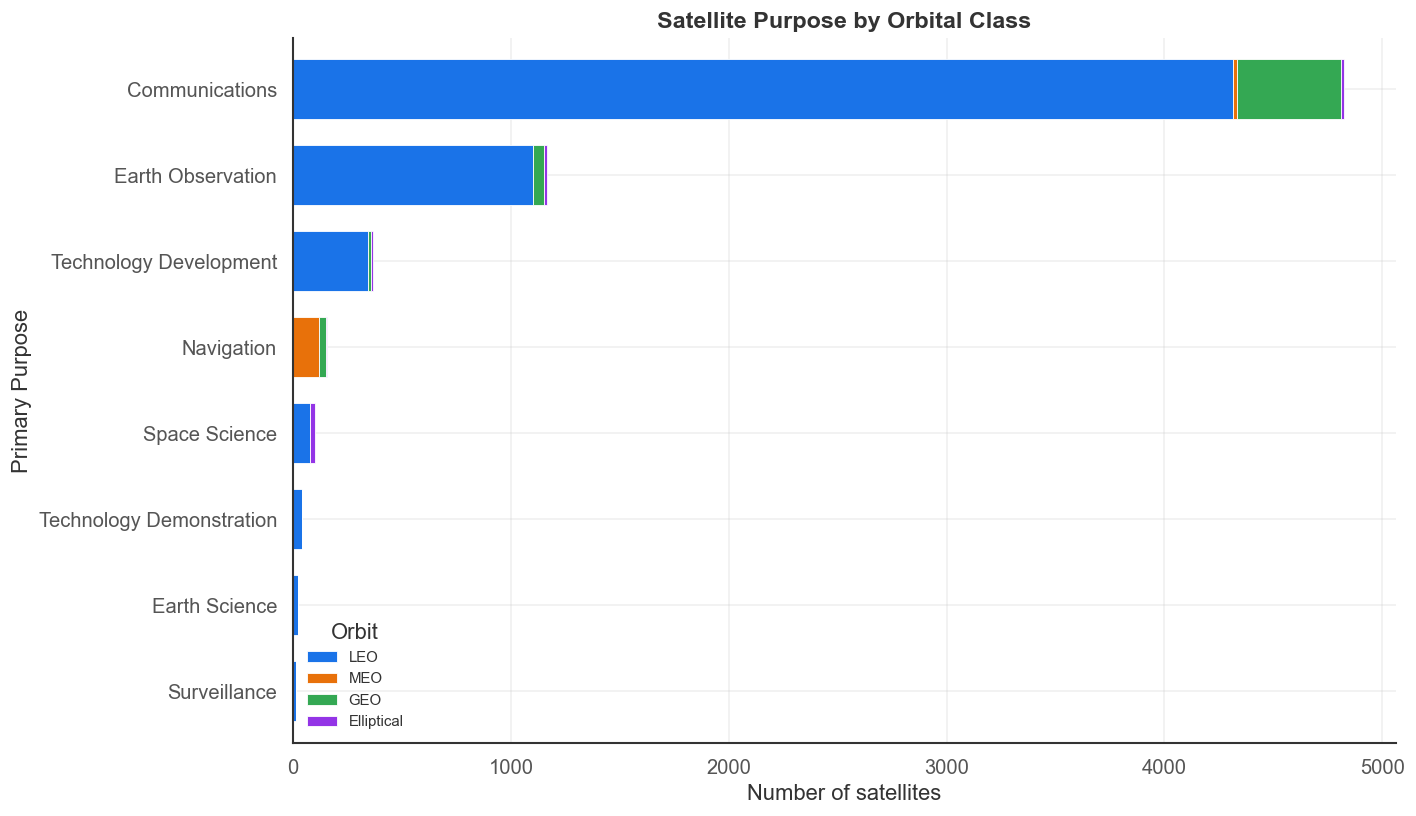

In [11]:
# Purpose breakdown by orbit class: clean stacked bar
purpose_orbit = pd.crosstab(df["Primary Purpose"], df["Class of Orbit"])
top_purposes = df["Primary Purpose"].value_counts().head(8).index
purpose_orbit_top = purpose_orbit.loc[purpose_orbit.index.isin(top_purposes)]
purpose_orbit_top = purpose_orbit_top.loc[purpose_orbit_top.sum(axis=1).sort_values(ascending=True).index]

fig, ax = plt.subplots(figsize=(12, 7))
orbit_order = ["LEO", "MEO", "GEO", "Elliptical"]
existing_orbits = [o for o in orbit_order if o in purpose_orbit_top.columns]
purpose_orbit_top[existing_orbits].plot(
    kind="barh", stacked=True, ax=ax,
    color=[PALETTE.get(o, "#999999") for o in existing_orbits],
    width=0.7, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Number of satellites")
ax.set_title("Satellite Purpose by Orbital Class", fontweight="bold", fontsize=14)
ax.legend(title="Orbit", fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig("img/purpose_orbit.png", bbox_inches="tight", facecolor="white", dpi=150)
plt.show()

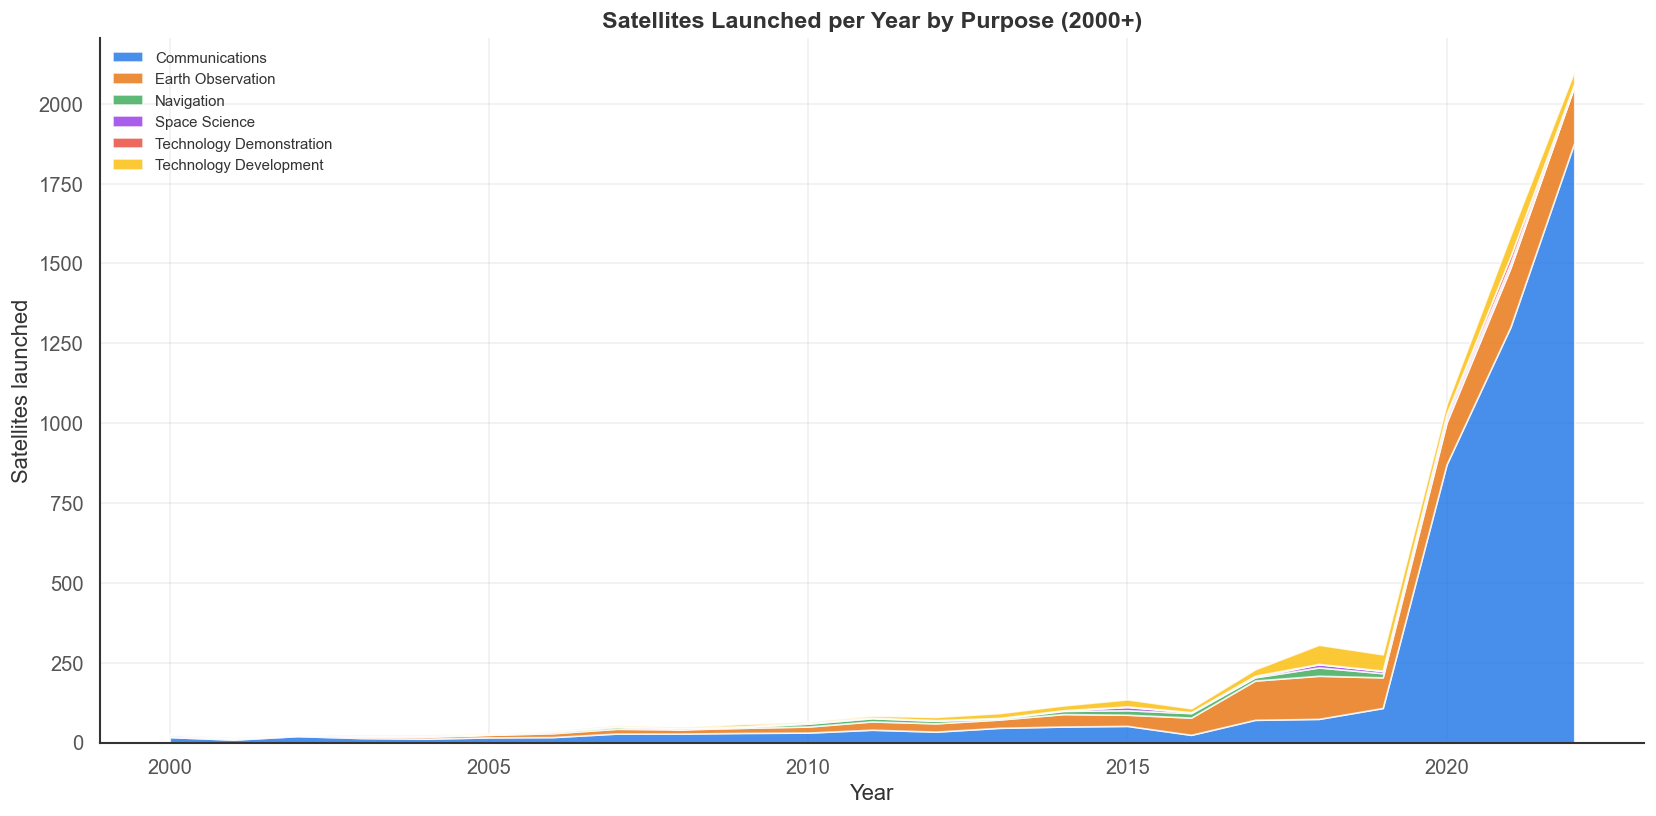


Communications satellites account for 4,823 (71.8%) of all operational satellites.
The explosion in launches since 2019 is almost entirely driven by communications (Starlink, OneWeb).


In [12]:
# Purpose evolution over time: stacked area
top6_purposes = df["Primary Purpose"].value_counts().head(6).index.tolist()
purpose_year = (df[df["Primary Purpose"].isin(top6_purposes)]
                .groupby(["Launch Year", "Primary Purpose"])
                .size()
                .unstack(fill_value=0))
purpose_year = purpose_year[purpose_year.index >= 2000]

purpose_colors = ["#1a73e8", "#e8710a", "#34a853", "#9334e6", "#ea4335", "#fbbc04"]
fig, ax = plt.subplots(figsize=(14, 7))
ax.stackplot(purpose_year.index, purpose_year.T, labels=purpose_year.columns,
             colors=purpose_colors[:len(purpose_year.columns)], alpha=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("Satellites launched")
ax.set_title("Satellites Launched per Year by Purpose (2000+)", fontweight="bold", fontsize=14)
ax.legend(fontsize=9, frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

comm_count = df[df["Primary Purpose"] == "Communications"].shape[0]
print(f"\nCommunications satellites account for {comm_count:,} ({comm_count/len(df)*100:.1f}%) of all operational satellites.")
print("The explosion in launches since 2019 is almost entirely driven by communications (Starlink, OneWeb).")

## 10. Operator Concentration: The Mega-Constellation Effect

A key insight for our narrative: how concentrated is orbital space among a few operators?

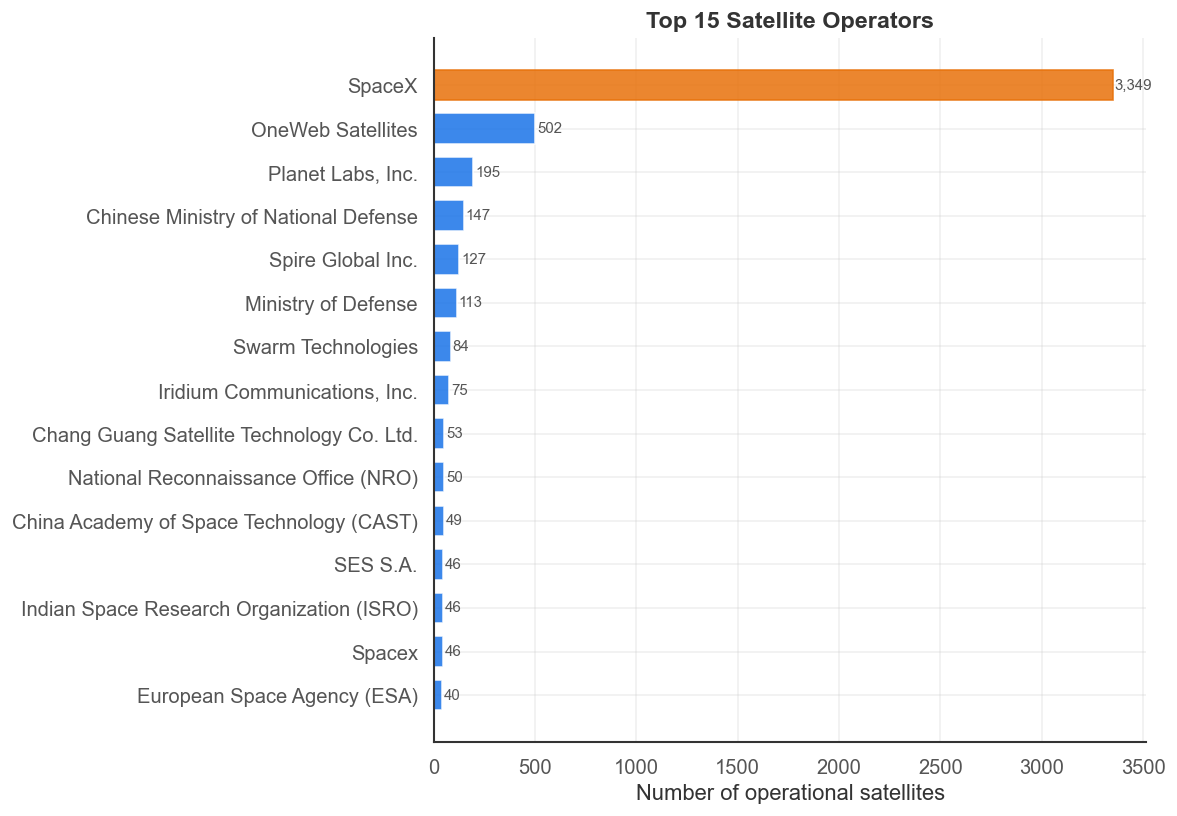


Concentration of orbital space:
  Top 1 operator:  3,349 satellites (49.9%)
  Top 5 operators: 4,320 satellites (64.3%)
  Top 10 operators: 4,695 satellites (69.9%)

The remaining 629 operators share the rest.


In [13]:
# Top 15 operators
top_operators = df["Operator/Owner"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_operators.index[::-1], top_operators.values[::-1],
               color=PALETTE["main"], height=0.7, alpha=0.85)
# Highlight #1 operator
bars[-1].set_color(PALETTE["accent"])
ax.set_xlabel("Number of operational satellites")
ax.set_title("Top 15 Satellite Operators", fontweight="bold", fontsize=14)

for bar, val in zip(bars, top_operators.values[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va="center", fontsize=9, color="#555555")

plt.tight_layout()
plt.show()

top1_pct = top_operators.iloc[0] / len(df) * 100
top5_pct = top_operators.iloc[:5].sum() / len(df) * 100
top10_pct = top_operators.iloc[:10].sum() / len(df) * 100
print(f"\nConcentration of orbital space:")
print(f"  Top 1 operator:  {top_operators.iloc[0]:,} satellites ({top1_pct:.1f}%)")
print(f"  Top 5 operators: {top_operators.iloc[:5].sum():,} satellites ({top5_pct:.1f}%)")
print(f"  Top 10 operators: {top_operators.iloc[:10].sum():,} satellites ({top10_pct:.1f}%)")
print(f"\nThe remaining {df['Operator/Owner'].nunique() - 10} operators share the rest.")

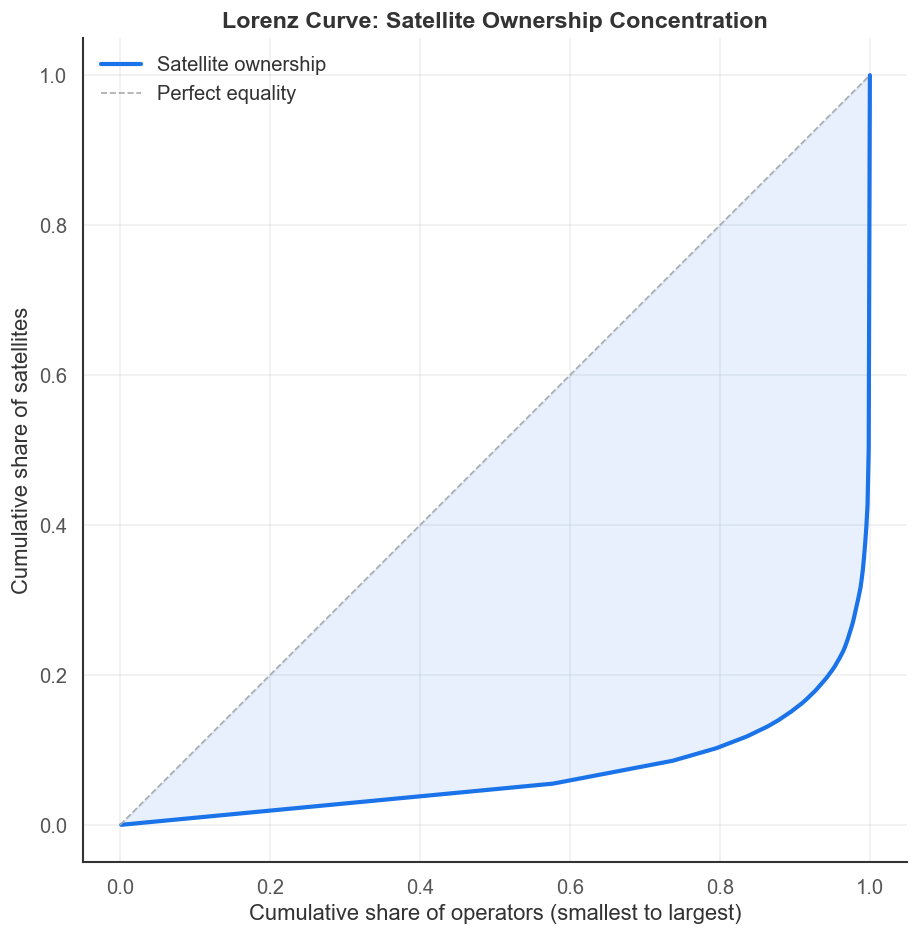


Gini coefficient of satellite ownership: 0.862
A value close to 1 indicates extreme concentration: a handful of operators control the majority of orbital space.


In [14]:
# Lorenz curve: inequality of satellite ownership among operators
operator_counts = df["Operator/Owner"].value_counts().sort_values().to_numpy()
cumulative_share = np.cumsum(operator_counts) / operator_counts.sum()
operator_share = np.arange(1, len(operator_counts) + 1) / len(operator_counts)

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(operator_share, cumulative_share, color=PALETTE["main"], linewidth=2.5,
        label="Satellite ownership")
ax.plot([0, 1], [0, 1], color="#aaaaaa", linestyle="--", linewidth=1, label="Perfect equality")
ax.fill_between(operator_share, cumulative_share, operator_share,
                alpha=0.1, color=PALETTE["main"])
ax.set_xlabel("Cumulative share of operators (smallest to largest)")
ax.set_ylabel("Cumulative share of satellites")
ax.set_title("Lorenz Curve: Satellite Ownership Concentration", fontweight="bold", fontsize=14)
ax.legend(frameon=False)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("img/lorenz.png", bbox_inches="tight", facecolor="white", dpi=150)
plt.show()

n = len(operator_counts)
gini = (2 * np.sum(np.arange(1, n+1) * np.sort(operator_counts)) / (n * np.sum(operator_counts))) - (n + 1) / n
print(f"\nGini coefficient of satellite ownership: {gini:.3f}")
print("A value close to 1 indicates extreme concentration: a handful of operators control the majority of orbital space.")

## 11. Launch Infrastructure

Where are satellites launched from, and with which vehicles? This gives a geographical anchor for the visualization.

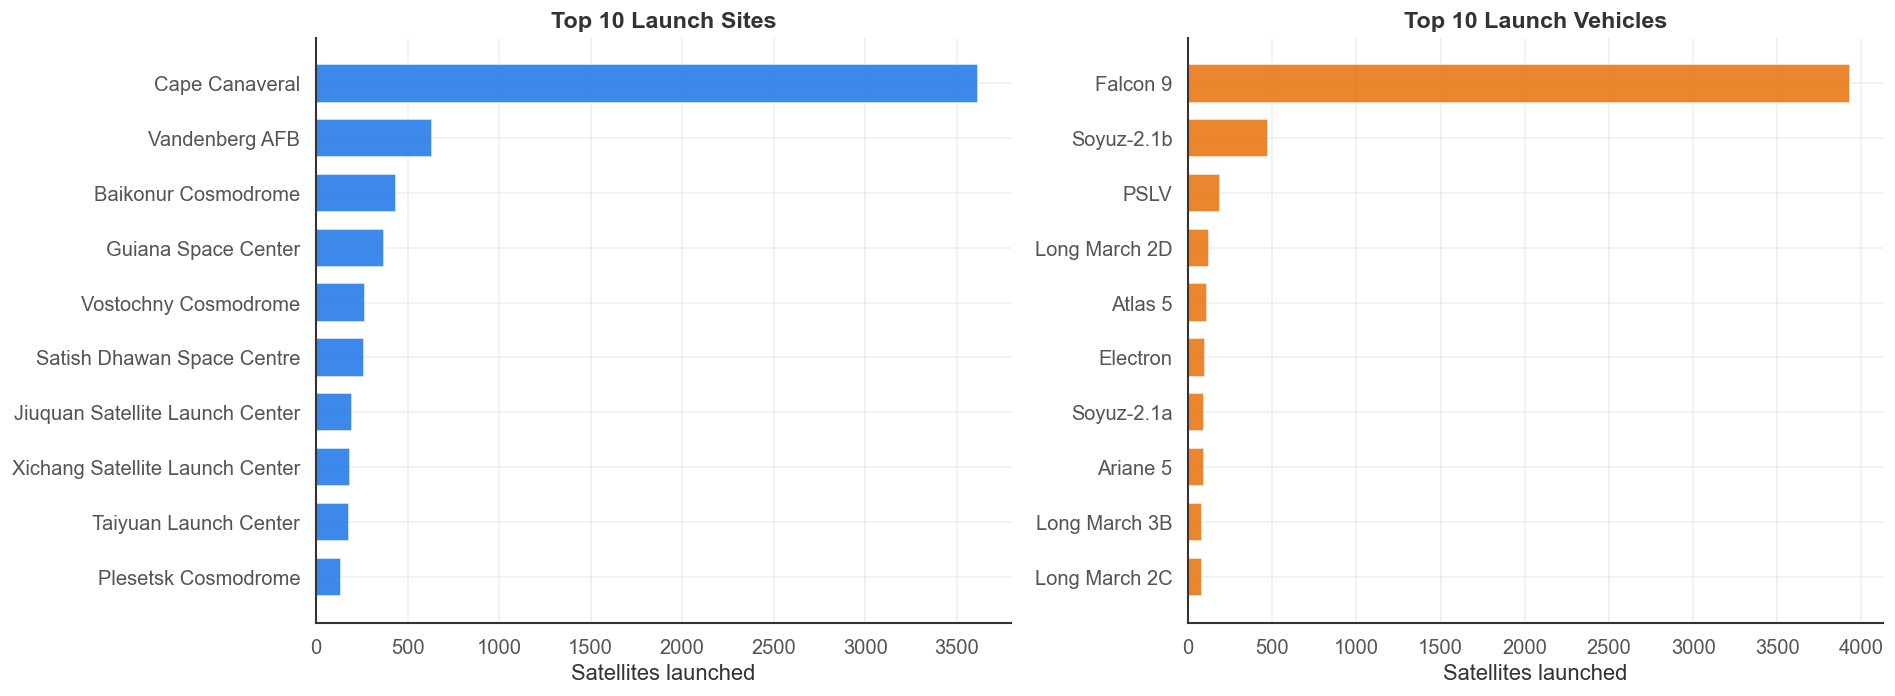

In [15]:
# Top launch sites and vehicles
top_sites = df["Launch Site"].value_counts().head(10)
top_vehicles = df["Launch Vehicle"].value_counts().head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.barh(top_sites.index[::-1], top_sites.values[::-1],
         color=PALETTE["main"], height=0.7, alpha=0.85)
ax1.set_xlabel("Satellites launched")
ax1.set_title("Top 10 Launch Sites", fontweight="bold", fontsize=14)

ax2.barh(top_vehicles.index[::-1], top_vehicles.values[::-1],
         color=PALETTE["accent"], height=0.7, alpha=0.85)
ax2.set_xlabel("Satellites launched")
ax2.set_title("Top 10 Launch Vehicles", fontweight="bold", fontsize=14)

plt.tight_layout()
plt.show()

## 12. Physical Characteristics: Mass and Lifetime

These **ratio** attributes let us look at the physical diversity of satellites. The course teaches that ratio data supports all visual channels (position, length, area, color saturation). We use histograms and box plots to show distributions.

C:\Users\Kevin\AppData\Local\Temp\ipykernel_16904\565100507.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(


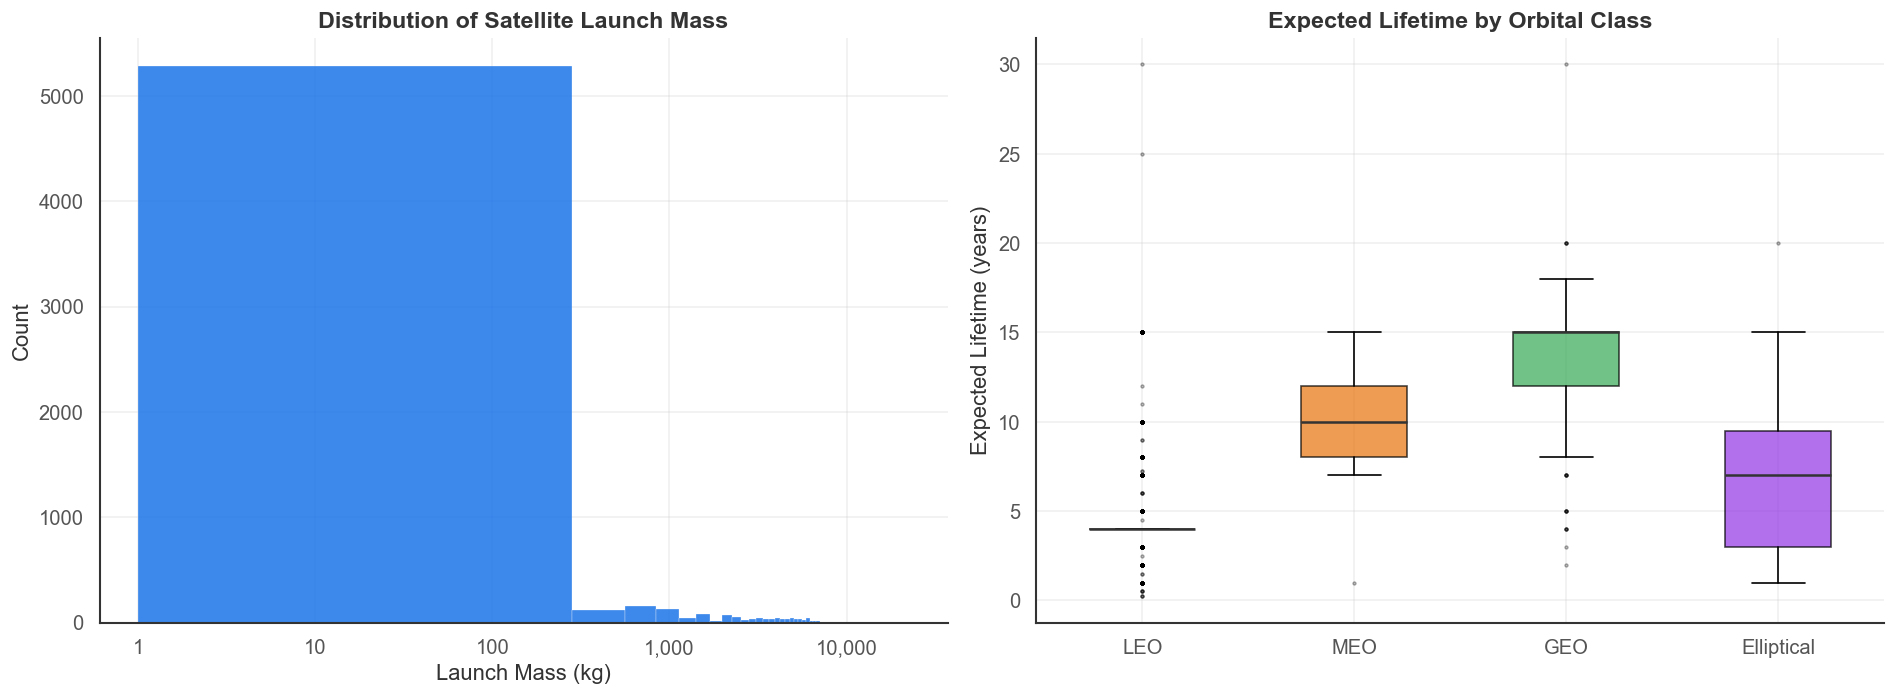


Median satellite mass: 260 kg
Mass range: 1.0 kg to 22,500 kg
The rise of CubeSats and small satellites has dramatically shifted the mass distribution toward lighter payloads.


In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Launch mass distribution
valid_mass = df["Launch Mass (kg.)"].dropna()
ax1.hist(valid_mass, bins=80, color=PALETTE["main"], edgecolor="white",
         linewidth=0.2, alpha=0.85)
ax1.set_xlabel("Launch Mass (kg)")
ax1.set_ylabel("Count")
ax1.set_title("Distribution of Satellite Launch Mass", fontweight="bold", fontsize=14)
ax1.set_xscale("log")
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Expected lifetime by orbit class
valid_lifetime = df.dropna(subset=["Expected Lifetime (yrs.)"])
orbit_order = ["LEO", "MEO", "GEO", "Elliptical"]
existing = [o for o in orbit_order if o in valid_lifetime["Class of Orbit"].unique()]
bp = ax2.boxplot(
    [valid_lifetime[valid_lifetime["Class of Orbit"] == o]["Expected Lifetime (yrs.)"].values
     for o in existing],
    labels=existing, patch_artist=True, widths=0.5,
    medianprops=dict(color="#333333", linewidth=1.5),
    flierprops=dict(marker=".", markersize=3, alpha=0.4))
for patch, o in zip(bp["boxes"], existing):
    patch.set_facecolor(PALETTE.get(o, "#999999"))
    patch.set_alpha(0.7)
ax2.set_title("Expected Lifetime by Orbital Class", fontweight="bold", fontsize=14)
ax2.set_ylabel("Expected Lifetime (years)")

plt.tight_layout()
plt.show()

median_mass = valid_mass.median()
print(f"\nMedian satellite mass: {median_mass:,.0f} kg")
print(f"Mass range: {valid_mass.min():.1f} kg to {valid_mass.max():,.0f} kg")
print("The rise of CubeSats and small satellites has dramatically shifted the mass distribution toward lighter payloads.")

## 13. Cross-Dimensional Exploration: Purpose x Orbit x User

The course emphasizes that multi-dimensional comparison reveals patterns invisible in single-variable views. We use a heatmap to show how purpose and orbit class relate, and how user type maps onto this structure.

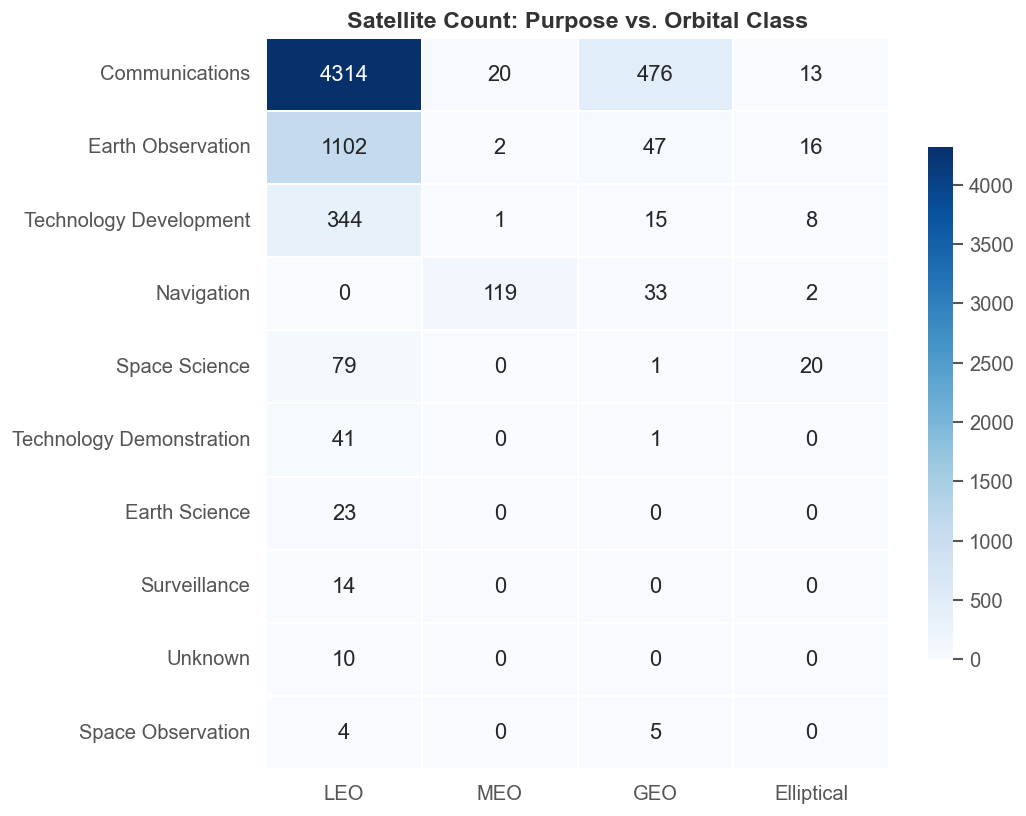

Key cross-dimensional patterns:
  - Communications satellites span LEO (mega-constellations) and GEO (traditional)
  - Earth Observation is almost exclusively LEO
  - Navigation is concentrated in MEO (GPS, Galileo, GLONASS, BeiDou)
  - Technology Development is entirely LEO (university CubeSats, experiments)


In [17]:
# Heatmap: Purpose x Orbit class
cross = pd.crosstab(df["Primary Purpose"], df["Class of Orbit"])
cross = cross.loc[cross.sum(axis=1).nlargest(10).index]
cross = cross[[c for c in ["LEO", "MEO", "GEO", "Elliptical"] if c in cross.columns]]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cross, annot=True, fmt="d", cmap="Blues", linewidths=1, linecolor="white",
            ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title("Satellite Count: Purpose vs. Orbital Class", fontweight="bold", fontsize=14)
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

print("Key cross-dimensional patterns:")
print("  - Communications satellites span LEO (mega-constellations) and GEO (traditional)")
print("  - Earth Observation is almost exclusively LEO")
print("  - Navigation is concentrated in MEO (GPS, Galileo, GLONASS, BeiDou)")
print("  - Technology Development is entirely LEO (university CubeSats, experiments)")

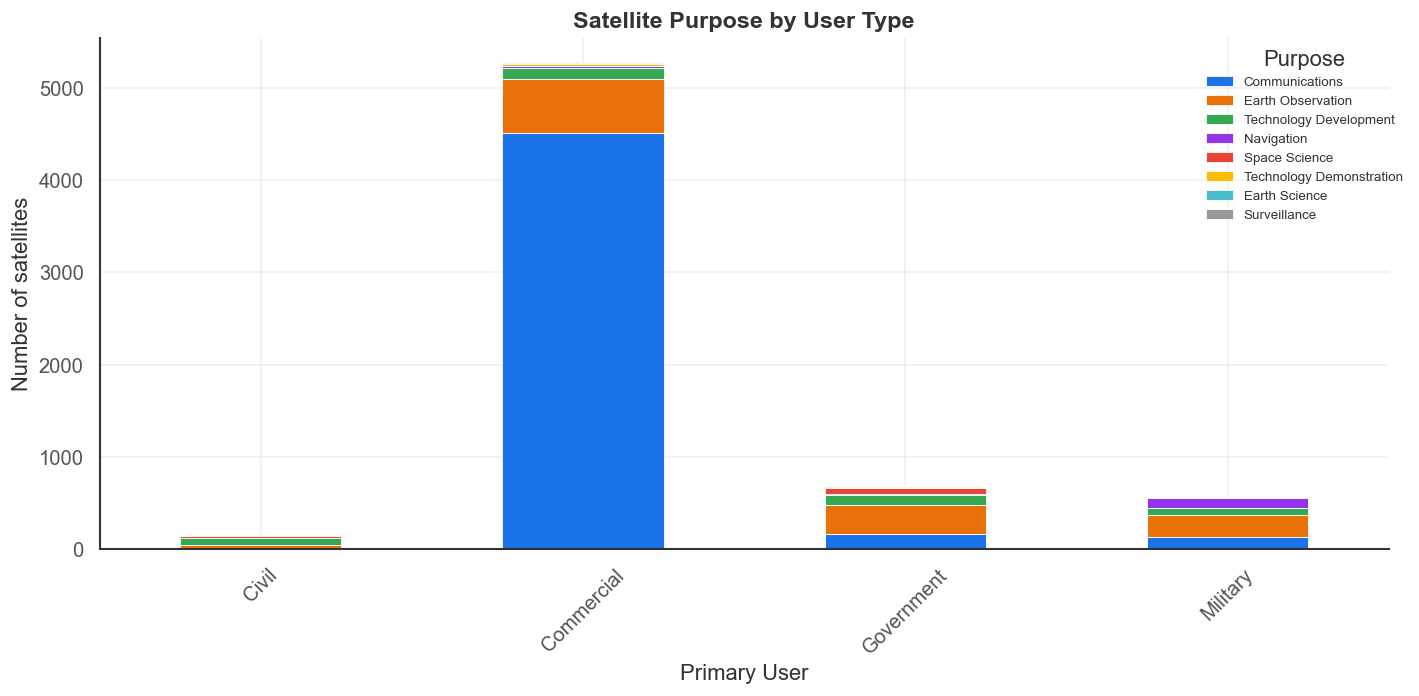

In [18]:
# User type x Purpose: who launches what?
user_purpose = pd.crosstab(df["Primary User"], df["Primary Purpose"])
user_purpose = user_purpose[df["Primary Purpose"].value_counts().head(8).index]

fig, ax = plt.subplots(figsize=(12, 6))
user_purpose.plot(kind="bar", stacked=True, ax=ax,
                  color=["#1a73e8", "#e8710a", "#34a853", "#9334e6",
                         "#ea4335", "#fbbc04", "#46bdc6", "#999999"],
                  edgecolor="white", linewidth=0.5)
ax.set_ylabel("Number of satellites")
ax.set_title("Satellite Purpose by User Type", fontweight="bold", fontsize=14)
ax.legend(title="Purpose", bbox_to_anchor=(1.02, 1), fontsize=8, frameon=False)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 14. Key Findings and Implications for the Final Visualization

### Summary of insights

1. **Explosive recent growth**: The majority of currently operational satellites were launched after 2019, driven almost entirely by communications mega-constellations (Starlink, OneWeb).

2. **Extreme concentration**: A tiny fraction of operators control a disproportionate share of orbital space. The Lorenz curve and Gini coefficient confirm this quantitatively.

3. **LEO dominance**: Low Earth Orbit contains the vast majority of satellites. The altitude vs. inclination scatter reveals distinct orbital "neighborhoods" corresponding to different mission types.

4. **Purpose-orbit coupling**: Different purposes map onto different orbital layers. Communications spans LEO and GEO, navigation clusters in MEO, Earth Observation is almost exclusively LEO.

5. **US dominance**: The USA operates more satellites than all other countries combined, largely due to SpaceX/Starlink.

6. **Data quality is high**: Minimal missing values in key fields. The main limitations are the sparse Dry Mass and Power columns (dropped) and the snapshot date (January 2023).

### Implications for visualization design

- The **temporal narrative** (growth over time) should be a central axis, possibly as a scrollytelling timeline
- The **orbital structure** (altitude vs. inclination) lends itself to a 2D polar or layered shell visualization
- The **geopolitical dimension** (country, operator) calls for an interactive world map or proportional symbol map
- The **concentration story** (Lorenz/Gini) can be a powerful narrative moment: "X% of operators control Y% of orbital space"
- The **purpose breakdown** works well as a filterable treemap or sunburst diagram

The dataset is well-suited for the project. It has enough depth across temporal, spatial, categorical, and quantitative dimensions to support 5-6 distinct, interconnected visualizations.